<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Drug_Food_Interactions_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d shayanhusain/drug-food-interactions-dataset

# Unziping the downloaded file
!unzip drug-food-interactions-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/shayanhusain/drug-food-interactions-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/56.9k [00:00<?, ?B/s]
100% 56.9k/56.9k [00:00<00:00, 198MB/s]
Archive:  drug-food-interactions-dataset.zip
  inflating: Drug to Food interactions Dataset.json  


In [4]:
df = pd.read_json('Drug to Food interactions Dataset.json')
df.head(11)

,name,reference,food_interactions
0,Lepirudin,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid herbs and supplements with anticoagulan...
1,Bivalirudin,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...","[Avoid echinacea., Avoid herbs and supplements..."
2,Peginterferon alfa-2a,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Drink plenty of fluids.]
3,Alteplase,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid herbs and supplements with anticoagulan...
4,Interferon alfa-n1,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid alcohol.]
5,Darbepoetin alfa,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Administer iron supplement. When initiating a...
6,Urokinase,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid herbs and supplements with anticoagulan...
7,Reteplase,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid herbs and supplements with anticoagulan...
8,Erythropoietin,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Administer iron supplement. When initiating a...
9,Salmon calcitonin,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Administer calcium supplement. Individuals wh...


In [5]:
df.tail(11)

,name,reference,food_interactions
1412,Belumosudil,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take at the same time every day. Belumosudil ...
1413,Fidanacogene elaparvovec,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Avoid excessive or chronic alcohol consumptio...
1414,Repotrectinib,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take with or without food. Take repotrectinib...
1415,L-Acetylleucine,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take with or without food.]
1416,Linzagolix,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take with or without food. The co-administrat...
1417,Vorasidenib,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take with or without food. A high-fat and hig...
1418,Pirtobrutinib,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take at the same time every day. Pirtobrutini...
1419,Fecal microbiota,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take on an empty stomach. For the oral admini...
1420,Revumenib,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take on an empty stomach. Prescribing informa...
1421,Deuruxolitinib,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",[Take with or without food. Food had negligibl...


In [6]:
df.shape

(1423, 3)

In [7]:
df.columns

Index(['name', 'reference', 'food_interactions'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1423 entries, 0 to 1422
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               1423 non-null   object
 1   reference          1423 non-null   object
 2   food_interactions  1423 non-null   object
dtypes: object(3)
memory usage: 33.5+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq
name,1423,1423,Benzgalantamine,1
reference,1423,1,"Knox C, Wilson M, Klinger CM, et al. DrugBank ...",1423
food_interactions,1423,1003,[Take with or without food.],76


## Univariate analysis

### Subtask:
Analyze and visualize the distribution of individual food interactions.


**Reasoning**:
Extract all unique food interactions, count their occurrences, and visualize the top N interactions with a bar plot.



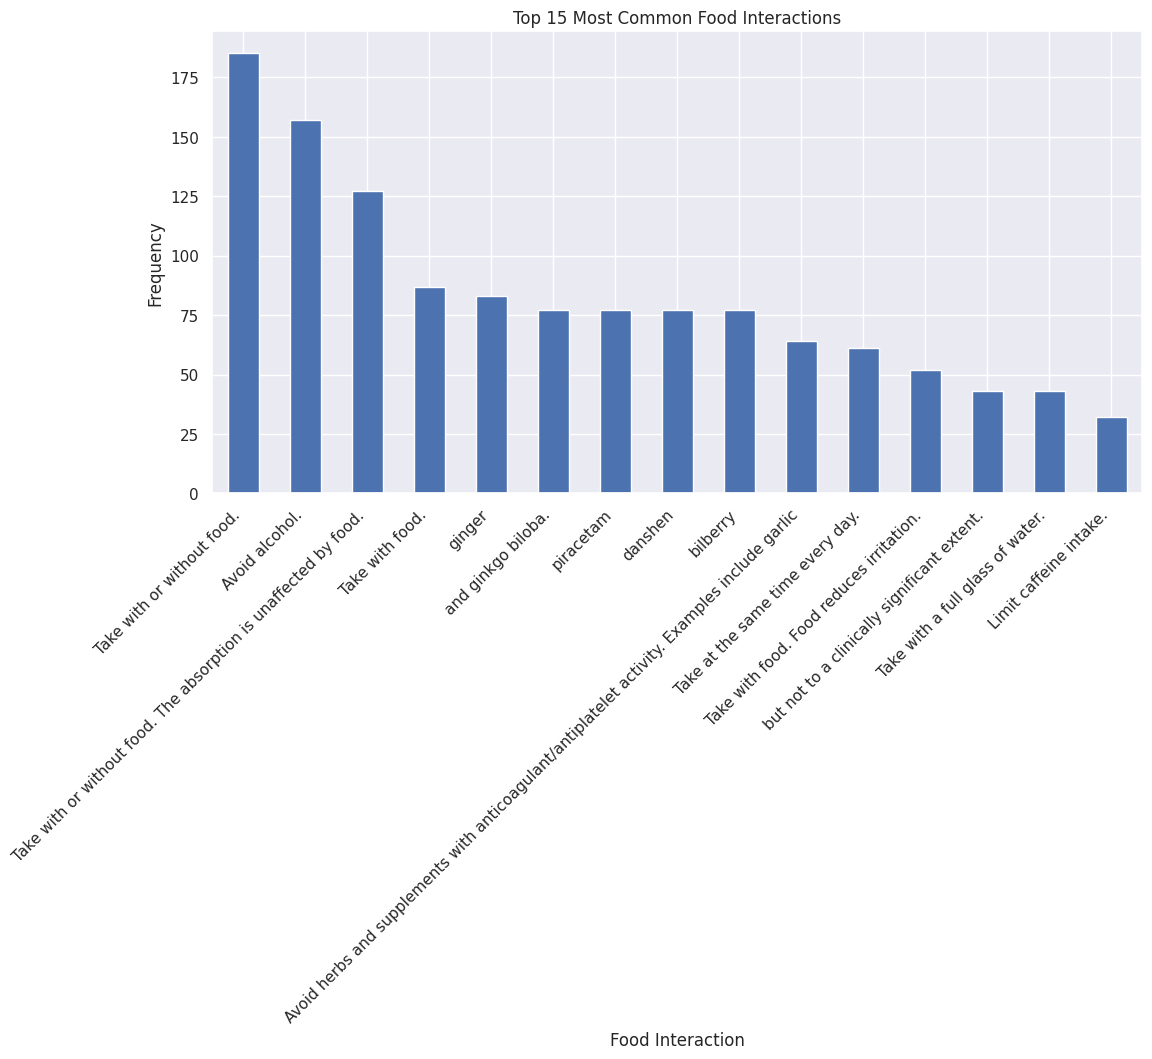

In [11]:
all_interactions = ', '.join(df['food_interactions']).split(', ')
interaction_counts = pd.Series(all_interactions).value_counts()

n_top_interactions = 15
top_interactions = interaction_counts.head(n_top_interactions)

plt.figure(figsize=(12, 6))
top_interactions.plot(kind='bar')
plt.title(f'Top {n_top_interactions} Most Common Food Interactions')
plt.xlabel('Food Interaction')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Bivariate analysis


**Reasoning**:
Create a binary matrix representing the presence of the top food interactions for each drug and display the first few rows.



In [12]:
# Create a list of all unique food interactions
all_interactions = ', '.join(df['food_interactions']).split(', ')
unique_interactions = list(set(all_interactions))

# Create a binary matrix
interaction_matrix = pd.DataFrame(0, index=df['name'], columns=unique_interactions)

# Populate the matrix
for index, row in df.iterrows():
    drug_name = row['name']
    interactions = row['food_interactions'].split(', ')
    for interaction in interactions:
        if interaction in unique_interactions:
            interaction_matrix.loc[drug_name, interaction] = 1

# Filter the matrix to include only the top interactions
top_interaction_columns = top_interactions.index.tolist()
interaction_matrix_top = interaction_matrix[top_interaction_columns]

display(interaction_matrix_top.head())

,Take with or without food.,Avoid alcohol.,Take with or without food. The absorption is unaffected by food.,Take with food.,ginger,and ginkgo biloba.,piracetam,danshen,bilberry,Avoid herbs and supplements with anticoagulant/antiplatelet activity. Examples include garlic,Take at the same time every day.,Take with food. Food reduces irritation.,but not to a clinically significant extent.,Take with a full glass of water.,Limit caffeine intake.
name,,,,,,,,,,,,,,,
Lepirudin,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Bivalirudin,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0
Peginterferon alfa-2a,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Alteplase,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0
Interferon alfa-n1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


**Reasoning**:
Visualize the relationships between drugs and the top food interactions using a heatmap to identify patterns.



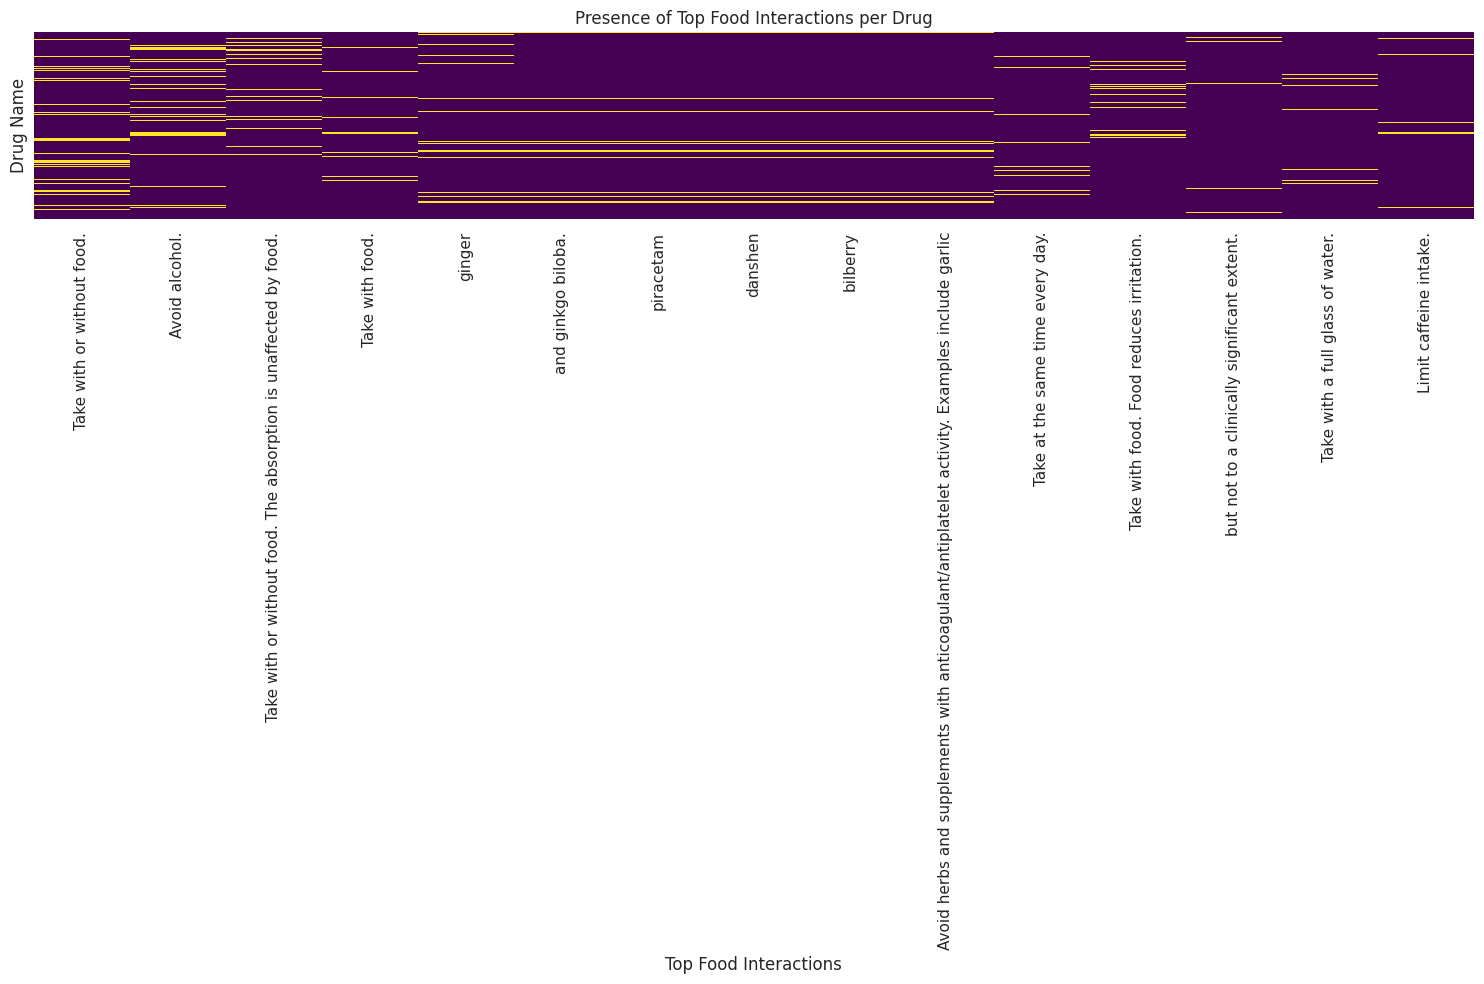

In [13]:
plt.figure(figsize=(15, 10))
sns.heatmap(interaction_matrix_top, cmap='viridis', cbar=False)
plt.title('Presence of Top Food Interactions per Drug')
plt.xlabel('Top Food Interactions')
plt.ylabel('Drug Name')
plt.xticks(rotation=90)
plt.yticks([]) # Hide y-axis labels due to large number of drugs
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The `food_interactions` column was successfully converted from a list of strings to a single comma-separated string for easier processing.
*   The top 15 most common food interactions were identified and visualized.
*   A binary matrix was created to show the presence or absence of the top food interactions for each drug.
*   A heatmap visualizing the relationships between drugs and the top food interactions was generated, indicating which drugs are associated with specific common food interactions.

### Insights or Next Steps

*   Further analysis could focus on identifying drugs that have a high number of food interactions or specific combinations of interactions.
*   Investigating the nature of these interactions (e.g., impact on efficacy or side effects) could provide valuable clinical insights.


# Thank you